# prep

In [ ]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [ ]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [ ]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [ ]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [ ]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [ ]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/csvs/'

# Data: loom

In [ ]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'
tab_name = 'loom_gsize'

experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
# path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


# 2a - loom angle diagram

# 2b - threshold aligned speed time series

['#f778a6', '#ef589e', '#de3797', '#c31789', '#a6017c', '#850178', '#660071', '#49006a']


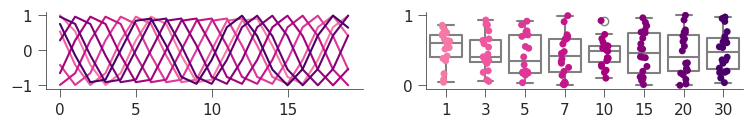

In [ ]:
# RGB hex values theme - for summary stats plots
group_names = [1,3,5,7,10,15,20,30]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.RdPu(i/(group_num+5)) for i in range(6,group_num+6)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

['1°: N=376', '3°: N=376', '5°: N=374', '7°: N=333', '10°: N=230', '15°: N=141', '20°: N=102', '30°: N=58']
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2b


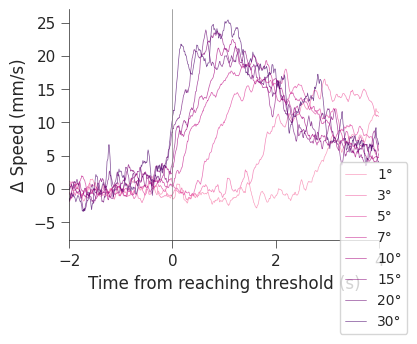

,1°_1,1°_2,1°_3,1°_4,1°_5,1°_6,1°_7,1°_8,1°_9,1°_10,...,30°_49,30°_50,30°_51,30°_52,30°_53,30°_54,30°_55,30°_56,30°_57,30°_58
0,1.263536,-5.290548,-11.729714,18.314356,1.312170,3.696352,10.961376,-3.024521,27.137626,-1.151295,...,-6.443971,-7.799707,23.643572,-12.493613,20.172583,36.258597,6.921804,6.833527,-8.352517,-14.257905
1,5.784322,-5.185127,-10.696829,14.675603,1.609778,5.256001,9.200790,-0.201263,24.920497,-1.418668,...,-7.785012,-7.992242,25.247985,-12.404451,17.239357,40.566194,8.779673,3.886938,-8.781268,-14.377606
2,15.536897,-4.616926,-10.780907,13.613532,2.295075,5.999538,7.329398,4.941173,22.470081,-2.040786,...,-8.008715,-8.449207,25.459313,-12.039492,15.344450,44.854484,10.446965,2.047005,-8.899627,-14.704831
3,29.541463,-3.759273,-11.659638,13.003569,3.368061,3.959028,6.837275,12.168714,20.618789,-2.993103,...,-7.671515,-8.841626,24.277556,-11.936616,13.824440,46.326082,12.137121,1.247369,-9.315252,-14.905834
4,30.341356,-2.562123,-11.764385,11.803220,2.584635,3.010638,7.686992,19.347412,19.366621,-2.864711,...,-6.034063,-8.667969,21.702714,-11.662546,12.389579,44.980990,13.189163,1.328985,-10.229319,-15.284945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,-1.461738,44.878847,68.629037,96.367521,33.565395,-4.015867,4.534362,8.379901,-19.118473,67.543698,...,25.473648,5.052808,-3.283561,-13.197956,-1.310227,42.464197,5.849224,1.244046,9.652354,34.709550
722,-0.440273,46.856006,68.179253,89.763960,35.358662,-3.212468,3.316372,10.007964,-18.957933,68.952148,...,26.178368,4.270262,-4.055693,-13.186689,-2.239037,44.603471,7.212136,3.962703,-3.565305,33.092695
723,0.513789,48.638000,67.729470,82.365280,38.657033,-2.770223,3.600205,11.390393,-19.192586,70.360598,...,26.883088,1.753176,-4.139682,-13.050696,-4.039997,46.592037,7.913804,6.613555,-2.208781,31.652516
724,1.400447,51.327101,67.279686,74.171482,43.460509,-2.064240,3.194289,12.527187,-19.341847,70.761972,...,27.587808,0.466065,-3.862651,-12.884880,-5.766836,47.725043,9.060832,11.594308,-0.424083,29.716935


In [ ]:
subpanel = '2b'

loom_thresholds = [1,3,5,7,10,15,20,30]
speed_mm_baseline = {n:[] for n in loom_thresholds};

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  for loom_threshold in loom_thresholds:
    for f in range(fish_num):
      cross_loom_idx = np.where(loom_subtend_angle[f]>loom_threshold)[0]
      if len(cross_loom_idx) == 0: continue # skip fish whose viewing never cross critical threshold
      align_idx = int(loom_on + cross_loom_idx[0])

      # Calculate baseline-subtracted speed
      baseline_speed = np.mean(f_speed[f][align_idx-int(6*121):align_idx])
      speed_baseline_norm = f_speed[f][align_idx-int(6*121):align_idx+int(6*121)] - baseline_speed
      speed_mm_baseline[loom_threshold].append(speed_baseline_norm)

# make time_sec relative to tap for plotting
pre = np.linspace(-6,0,6*121); post = np.linspace(0,6,6*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

metric = speed_mm_baseline
print([f"{gs}°: N={len(speed_mm_baseline[gs])}" for gs in loom_thresholds])
plt.figure(figsize=[4,3])
for ithreshold, loom_threshold in enumerate(loom_thresholds):
  plt.plot(rel_time,np.mean(metric[loom_threshold],axis=0),c=hex_colors[ithreshold],lw=0.5,alpha=0.7,label=f"{loom_threshold}°") # lw=3
plt.xlim(-2,4); plt.xticks([-2,0,2,4]);
plt.ylabel('Δ Speed (mm/s)'); plt.xlabel('Time from reaching threshold (s)')
plt.axvline(0,c='grey',linewidth=0.5);
plt.legend(bbox_to_anchor=(1.1,0.35),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

# save source data into csv - for time series, save out the visible part
ST, ED = -6, 6; st, ed = -2, 4; fps = 121

series_dict = {}
for group, samples in speed_mm_baseline.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}°_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 2c - latency to speed increase by threshold stats

['#f778a6', '#ef589e', '#de3797', '#c31789', '#a6017c', '#850178', '#660071', '#49006a']


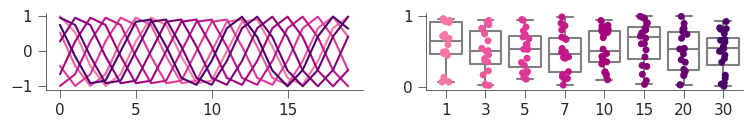

In [ ]:
# RGB hex values theme - for summary stats plots
group_names = [1,3,5,7,10,15,20,30]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.RdPu(i/(group_num+5)) for i in range(6,group_num+6)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2c


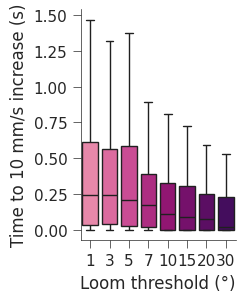


Time to reach 10 mm/s increase
Ns, means, and  sems for data:
1°: (N=372) 0.530, 0.042
3°: (N=370) 0.454, 0.033
5°: (N=371) 0.380, 0.026
7°: (N=332) 0.280, 0.022
10°: (N=230) 0.232, 0.021
15°: (N=141) 0.203, 0.024
20°: (N=102) 0.188, 0.026
30°: (N=58) 0.157, 0.032

Normality test (Shapiro-Wilk):
Group 1: W = 0.659, p = 1.2564722235e-26
Group 3: W = 0.696, p = 2.6253288843e-25
Group 5: W = 0.712, p = 9.2374697172e-25
Group 7: W = 0.670, p = 6.4961652863e-25
Group 10: W = 0.735, p = 6.6504101792e-19
Group 15: W = 0.732, p = 9.9941737847e-15
Group 20: W = 0.732, p = 2.3915043669e-12
Group 30: W = 0.690, p = 8.8829124348e-10
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 78.309, p = 3.0463273909e-14

Dunn's post hoc test with bonferroni correction:  [1, 3, 5, 7, 10, 15, 20, 30]
          1         2         3         4         5         6         7  \
1  1.000000  1.000000  1.000000  0.020345  0.000079  0.000019  0.000027   
2  1.000000  1.00

,1°,3°,5°,7°,10°,15°,20°,30°
0,1.735036,0.373572,0.323763,0.514700,0.257350,0.000000,0.498611,0.349028
1,0.606017,0.000000,0.000000,0.415080,0.157731,0.290857,0.108032,0.307477
2,0.008302,0.307159,0.763748,0.398477,0.107991,0.565093,0.432130,0.000000
3,0.000000,0.415080,0.763748,0.365509,0.240995,0.016623,0.000000,0.000000
4,0.897158,0.091377,0.000000,0.681176,0.573403,0.149324,0.033191,0.000000
...,...,...,...,...,...,...,...,...
367,0.338418,0.420960,1.972732,NaN,NaN,NaN,NaN,NaN
368,5.183581,0.660329,0.082541,NaN,NaN,NaN,NaN,NaN
369,0.264132,0.635566,0.321910,NaN,NaN,NaN,NaN,NaN
370,0.511755,NaN,0.899698,NaN,NaN,NaN,NaN,NaN


In [ ]:
subpanel = '2c'

loom_thresholds = [1,3,5,7,10,15,20,30]
speed_mm_baseline = {n:[] for n in loom_thresholds};
time_to_10mms = {n: [] for n in loom_thresholds};

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  for loom_threshold in loom_thresholds:
    for f in range(fish_num):

      cross_loom_idx = np.where(loom_subtend_angle[f]>loom_threshold)[0]
      if len(cross_loom_idx) == 0: continue # skip fish whose viewing never cross critical threshold
      align_idx = int(loom_on + cross_loom_idx[0])

      # Calculate baseline-normalized speed
      baseline_speed = np.mean(f_speed[f][align_idx-int(6*121):align_idx])
      speed_baseline_norm = f_speed[f][align_idx-int(6*121):align_idx+int(6*121)] - baseline_speed
      speed_mm_baseline[loom_threshold].append(speed_baseline_norm)

      # Calculate time to reach 10 mm/s increase
      post_align_speed = speed_baseline_norm[int(6*121):]  # Speed after alignment point
      cross_10mms = np.where(post_align_speed >= 10)[0]
      if len(cross_10mms) > 0: time_to_10mms[loom_threshold].append(cross_10mms[0] / fps)  # Convert frames to seconds

# plot
plt.figure(figsize=[2,3])
sns.boxplot(data=time_to_10mms, palette=hex_colors, whis=1.5, showfliers=False)
plt.xlabel('Loom threshold (°)'); plt.ylabel('Time to 10 mm/s increase (s)')
sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f'\nTime to reach 10 mm/s increase')
# stats
group_values = time_to_10mms  # Use time_to_10mms for stats
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}°: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')


## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[f'{key}°'] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 2d - turning PDF by threshold

['#f778a6', '#ef589e', '#de3797', '#c31789', '#a6017c', '#850178', '#660071', '#49006a']


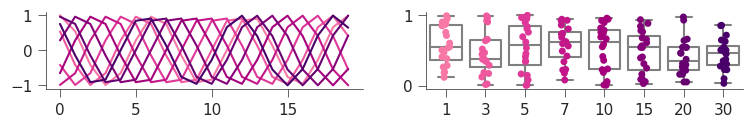

In [ ]:
# RGB hex values theme - for summary stats plots
group_names = [1,3,5,7,10,15,20,30]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.RdPu(i/(group_num+5)) for i in range(6,group_num+6)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2d- full


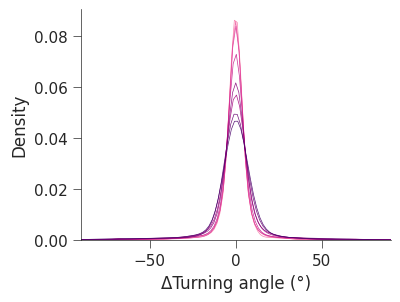

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2d - inset


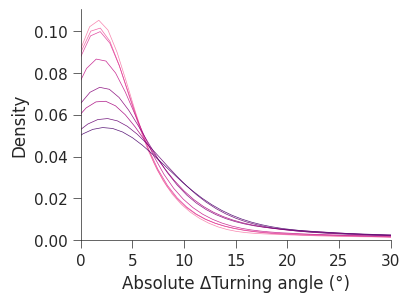

,1°,3°,5°,7°,10°,15°,20°,30°
0,-0.920639,6.339738,6.591586,3.924974,-13.641044,-5.175103,-3.965042,12.711136
1,0.515127,4.749600,6.675300,3.187295,-17.864067,-7.153261,-7.166590,11.915447
2,1.823221,3.416654,6.227631,2.489800,-18.290507,-7.802156,-9.106401,9.786892
3,2.639713,2.020259,5.604944,1.571786,-17.552350,-6.966624,-9.396086,6.933829
4,2.602313,0.716868,5.268598,0.755763,-15.547972,-4.628700,-8.729160,4.721976
...,...,...,...,...,...,...,...,...
14683,18.714542,-7.631976,NaN,NaN,NaN,NaN,NaN,NaN
14684,16.607656,-7.161634,NaN,NaN,NaN,NaN,NaN,NaN
14685,13.196689,-5.951809,NaN,NaN,NaN,NaN,NaN,NaN
14686,8.754728,-4.324386,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
group_sizes = [4,6,8]; group_values = {n: [] for n in group_sizes}

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'0.1 post threshold':(i,i+0.1) for i in [0]}

loom_thresholds = [1,3,5,7,10,15,20,30]
# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in loom_thresholds}
metrics = {g: {w: [] for w in window_times} for g in loom_thresholds}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # load loom perception info
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))
  # per-experiment metrics container
  metrics_exp = {w: {'iqr': [], 'p90': [], 'exp': exp} for w in window_times}

  # loop over loom_thresholds
  for threshold in loom_thresholds:
    for f in range(fish_num):
      # identify
      cross_loom_idx = np.where(loom_subtend_angle[f]>threshold)[0]
      if len(cross_loom_idx) == 0: continue # skip fish whose viewing never cross critical threshold
      align_idx = int(loom_on + cross_loom_idx[0])

      # loop over windows
      for w_name, (t_start, t_end) in window_times.items():
        # compute start and stop frame indices relative to tap
        i0 = align_idx + int(t_start * fps)
        i1 = align_idx + int(t_end * fps)

        # collect |Δθ| for all fish in this experiment
        for f in range(fish_num):
          theta = f_heading[f, i0:i1]
          if len(theta) <= dt: continue
          # # wrapped delta heading in degrees
          dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
          # abs_dtheta = np.abs(dtheta)
          pooled_dtheta[threshold][w_name].append(dtheta)

    if not pooled_dtheta[threshold][w_name]: continue
    all_dtheta = np.concatenate(pooled_dtheta[threshold][w_name]);
    all_abs_dtheta = np.concatenate(np.abs(pooled_dtheta[threshold][w_name]))
    # compute metrics
    metrics_exp[w_name]['iqr'] = np.percentile(all_dtheta, 75) - np.percentile(all_dtheta, 25)
    metrics_exp[w_name]['p90'] = np.percentile(all_abs_dtheta, 90)

    # append per experiment metrics to group-level
    for w_name in window_times:
      metrics[threshold][w_name].append(metrics_exp[w_name])

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())

# pdf
plt.figure(figsize=(4,3))
for ig, g in enumerate(loom_thresholds):
  for iw, w_name in enumerate(window_list):
    data = pooled_dtheta[g][w_name]
    if len(data) == 0: continue
    sns.kdeplot(data, fill=False, c=hex_colors[ig], alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

plt.xlabel('ΔTurning angle (°)'); plt.ylabel('Density')
plt.xlim(-90,90)
sns.despine();
subpanel = '2d- full'
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# inset
plt.figure(figsize=(4,3))
for ig, g in enumerate(loom_thresholds):
  for iw, w_name in enumerate(window_list):
    data = np.abs(pooled_dtheta[g][w_name])
    if len(data) == 0: continue
    sns.kdeplot(data, fill=False, c=hex_colors[ig], alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Density')
plt.xlim(0,30); sns.despine()
subpanel = '2d - inset'
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  for g in loom_thresholds:
    data = pooled_dtheta[g][w_name]
    col_name = f"{g}°"
    series_dict[col_name] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
subpanel = '2d'
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 2e - critical angle CDF

Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile, max]
(N=376) [0.64864865 0.78239203 0.87257618], 0.9944903581267218
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6721763085399449
0.8057851239669421
0.9132231404958677
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2e


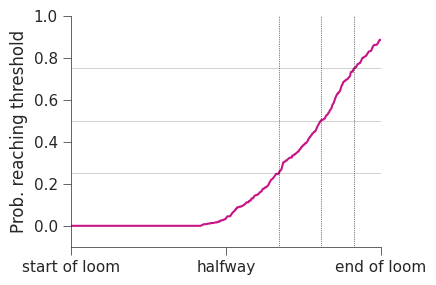

,global_inform_probability
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
721,0.878639
722,0.883012
723,0.885638
724,0.885638


In [ ]:
subpanel = '2e'

loom_threshold = 7
ind_inform_time = []; ind_inform_cumulate = []
group_inform_time = []; group_inform_cumulate = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue

  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  # get when fish reach critical loom angle
  reach_idx=[]; reach_array=[] # cumulative
  for f in range(fish_num):
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    if len(f_reach)==0: # never reach
      ind_inform_time.append(np.nan)
      ind_inform_cumulate.append(np.full(loom_len,0))
      reach_idx.append(np.nan);
      reach_array.append(np.full(loom_len,0))
    else:
      ind_inform_time.append(f_reach[0]/loom_len)
      ind_inform_cumulate.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      reach_idx.append(f_reach[0]);
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))

  group_inform_time.append(np.nanmean(reach_idx)/loom_len)
  group_inform_cumulate.append(np.nanmean(reach_array,axis=0))

# individual level (across groups)
print('Time reaching threshold (% of trial length):')
print('N, [25, 50, 75 percentile, max]')
print(f'(N={len(ind_inform_time)}) {np.nanpercentile(ind_inform_time,[25,50,75])}, {np.nanmax(ind_inform_time)}')

# plot
print('Reaching threshold probability:')
early_cutoffs = []; late_cutoffs = []; middle_cutoffs = []

plt.figure(figsize=[4,3])
arr, new_len = resample_to_max_length(ind_inform_cumulate) # warp to the same length
plt.plot(np.arange(new_len),np.nanmean(arr,axis=0),color='mediumvioletred')
plt.axvline(new_len,color='gray',lw=0.5);

for line in [0.25,0.5,0.75]:
  plt.axvline(np.argmax(np.nanmean(arr,axis=0)>=line),color='black',linestyle=':',lw=0.5)
  plt.axhline(line,color='black',alpha=0.25,lw=0.5)
print('\ntime to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)')
[print(f'{np.argmax(np.nanmean(arr,axis=0)>=pct)/new_len}') for pct in [0.25,0.5,0.75]]

early_cutoffs = np.argmax(np.nanmean(arr,axis=0)>=0.25)/new_len
middle_cutoffs = np.argmax(np.nanmean(arr,axis=0)>=0.5)/new_len
late_cutoffs = np.argmax(np.nanmean(arr,axis=0)>=0.75)/new_len

plt.xlim([0,arr.shape[1]]); plt.ylim([-0.1,1]);
plt.xticks([0,int(new_len)/2,int(new_len)],['start of loom','halfway','end of loom'])
sns.despine(); plt.ylabel('Prob. reaching threshold');
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
series_dict['global_inform_probability'] = pd.Series(np.nanmean(arr,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## + assignment cartoon

# 2f-p assign inform status for ind & group

In [ ]:
# calculate global cutoffs
# calculate global time to threshold cutoffs
loom_threshold = 7

ind_fish_df = {}; ind_inform_cumulate = []
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue

  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  reach_idx=[]; reach_array=[]
  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(loom_dur)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_inform_cumulate.append(np.full(loom_len,0))
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      ind_inform_cumulate.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))

for key in ind_fish_df.keys():
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('Time reaching threshold (% of trial length):')
print('N, [25, 50, 75 percentile], max')
print(f"(N={ind_fish_df['ind_time'].shape[0]}) {np.nanpercentile(ind_fish_df['ind_time'],[25,50,75])}")
cum_arr, new_len =resample_to_max_length(ind_inform_cumulate)
global_middle_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.5)/new_len
print(f'global middle cutoffs = {global_middle_cutoffs}')
global_early_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.25)/new_len
global_late_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.75)/new_len

Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=376) [0.64864865 0.78239203 0.87257618]
global middle cutoffs = 0.8057851239669421


In [ ]:
# assign early late based on global cutoffs
loom_threshold = 7
bin_num = 20
ind_fish_df = {};
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status',\
           'speed_before_loom']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue # restrict to groups of 4 or larger

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  reach_array=[] # cumulative
  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(loom_dur)

    # bin the speed into 10% time of loom duration
    f_speed_bins = np.array_split(f_speed[f][loom_off-loom_len:loom_off],bin_num)
    ind_fish_df['speed_before_loom'].append([np.nanmean(bin) for bin in f_speed_bins])

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_fish_df['ind_status'].append('late')
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      if f_reach[0]/loom_len < global_middle_cutoffs:
        ind_fish_df['ind_status'].append('early')
      else:
        ind_fish_df['ind_status'].append('late')

  # assign group status
  group_inform_time = np.argmax(np.nanmean(reach_array,axis=0)>=0.5)
  [ind_fish_df['group_time'].append(group_inform_time/loom_len) for f in range(fish_num)]
  if group_inform_time/loom_len < global_middle_cutoffs:
    [ind_fish_df['group_status'].append('early') for f in range(fish_num)]
  else:
    [ind_fish_df['group_status'].append('late') for f in range(fish_num)]

for key in ind_fish_df.keys():
  # if key == 'speed_before_loom': continue
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('\nEARLY group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="early"])))
print('LATE group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="late"])))

print('\nearly fish N = ', np.sum(ind_fish_df["ind_status"]=="early"))
print('late fish N = ', np.sum(ind_fish_df["ind_status"]=="late"))

print('\nearly fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='early')))
print('early fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='late')))
print('late fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='early')))
print('late fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='late')))
print('naive fish in EARLY group N = ', np.sum(np.isnan(ind_fish_df['ind_time'])*(ind_fish_df['group_status']=='early')))
print('naive fish in LATE group N = ', np.sum(np.isnan(ind_fish_df['ind_time'])*(ind_fish_df['group_status']=='late')))


EARLY group N =  33
LATE group N =  29

early fish N =  188
late fish N =  188

early fish in EARLY group N =  153
early fish in LATE group N =  35
late fish in EARLY group N =  49
late fish in LATE group N =  139
naive fish in EARLY group N =  10
naive fish in LATE group N =  33


## 2f - earliest and latest fish speed time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2f


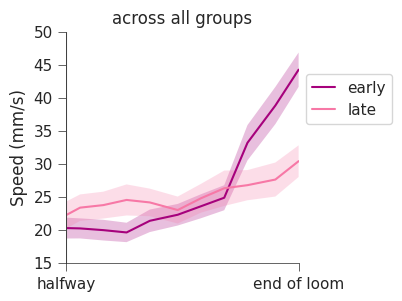

N = 94, 51


,early_fish_1,early_fish_2,early_fish_3,early_fish_4,early_fish_5,early_fish_6,early_fish_7,early_fish_8,early_fish_9,early_fish_10,...,late_fish_42,late_fish_43,late_fish_44,late_fish_45,late_fish_46,late_fish_47,late_fish_48,late_fish_49,late_fish_50,late_fish_51
0,6.172371,15.153770,29.928928,35.551912,33.710369,29.028675,11.190586,41.772042,10.912973,19.349251,...,13.162600,12.254790,45.925214,24.936270,54.499655,36.032971,38.942049,27.812515,34.233569,42.675729
1,8.931636,13.752976,15.776255,8.447298,10.257836,32.536199,25.161350,18.749800,6.730302,11.160339,...,9.542345,9.443964,40.867252,23.283638,30.770384,16.310887,20.657617,16.649681,66.602200,25.038311
2,36.016667,24.911508,8.585680,28.270537,11.265308,61.185145,24.853424,33.860032,12.439404,53.578266,...,17.604029,23.152409,55.119474,22.381884,60.150623,11.001981,12.103831,25.312902,67.169297,19.683426
3,37.549689,12.345205,5.451504,54.593268,16.432829,20.215420,8.665197,4.354347,15.217908,44.885977,...,15.767914,60.417619,25.071574,26.547763,37.323904,14.179618,9.779147,13.807090,48.260839,25.122407
4,22.442973,35.556201,6.469256,14.373510,8.489832,30.728817,29.897538,17.840507,12.287015,23.400096,...,14.244857,31.713758,54.723966,21.915291,40.461759,32.859829,16.617928,24.494934,9.691123,40.800027
5,16.172247,32.811804,6.914757,17.091009,27.128277,36.748491,15.382445,26.288315,14.915500,25.497263,...,10.690566,17.198966,28.346406,30.938284,46.899176,11.592149,31.998282,15.393464,43.295490,36.480064
6,17.491586,15.649055,14.319411,21.315136,18.920697,13.466355,16.248158,22.072870,9.155677,19.704605,...,9.594825,10.242635,36.058488,43.885001,20.224812,20.780803,15.261927,9.549128,15.277963,29.127669
7,20.621850,9.021817,7.674714,22.994644,10.851203,14.414793,25.809156,19.919257,6.937720,13.863667,...,16.180431,6.007784,30.285195,25.263571,41.550382,16.620688,12.027893,19.597274,21.802321,54.590186
8,10.596303,9.671799,9.180994,5.440093,9.504711,34.812470,18.713784,4.746246,26.289683,10.630839,...,23.581337,6.426647,10.634352,28.931756,40.761473,24.635778,8.771305,10.158837,27.125541,29.993059
9,9.792112,7.780776,20.865474,5.003352,3.971618,32.599487,40.373814,6.172021,3.021780,21.831713,...,12.381132,4.110968,9.717398,37.316181,22.227502,9.577637,17.256272,38.827740,19.329338,42.060610


In [ ]:
subpanel = '2f'
hex_colorz = ['#a6017c', '#f778a6'];
categories = ['early','late']

# make time_sec relative to tap for plotting
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# masks
reall_early_fish = ind_fish_df['ind_time'] < global_early_cutoffs
reall_late_fish = ind_fish_df['ind_time'] > global_late_cutoffs

early_speeds = ind_fish_df['speed_before_loom'][reall_early_fish]
late_speeds = ind_fish_df['speed_before_loom'][reall_late_fish]

# plot
plt.figure(figsize=[3, 3])
plt.plot(rel_sec, np.nanmean(early_speeds,axis=0),color=hex_colorz[0],label='early')
plt.fill_between(rel_sec,np.nanmean(early_speeds,axis=0)-stats.sem(early_speeds,axis=0),\
                 np.nanmean(early_speeds,axis=0)+stats.sem(early_speeds,axis=0),color=hex_colorz[0],alpha=0.25,lw=0)
plt.plot(rel_sec, np.nanmean(late_speeds,axis=0),color=hex_colorz[1],label='late')
plt.fill_between(rel_sec,np.nanmean(late_speeds,axis=0)-stats.sem(late_speeds,axis=0),\
                 np.nanmean(late_speeds,axis=0)+stats.sem(late_speeds,axis=0),color=hex_colorz[1],alpha=0.25,lw=0)
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5)
plt.axvline(0.5,color='gray'); plt.ylim(15,50); plt.xlim(0.5,1)
plt.xticks([0.5,1],['halfway','end of loom'])
plt.ylabel('Speed (mm/s)')
sns.despine(); plt.title(f'across all groups')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()
print(f"N = {early_speeds.shape[0]}, {late_speeds.shape[0]}")

# save source data into csv
series_dict = {}
for i, s in enumerate(early_speeds): series_dict[f'early_fish_{i+1}'] = pd.Series(s)
for i, s in enumerate(late_speeds): series_dict[f'late_fish_{i+1}'] = pd.Series(s)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## 2g - stats of 2f

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2g


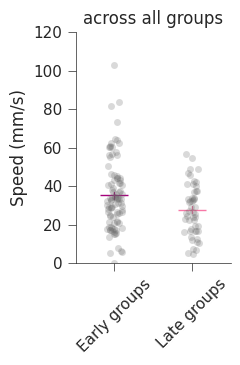

,early_fish_in_early_group,early_fish_in_late_group
0,31.447789,37.495029
1,31.238827,11.905659
2,18.485549,4.709748
3,44.465946,10.388162
4,17.059784,16.938409
...,...,...
89,34.060546,NaN
90,43.346916,NaN
91,33.297634,NaN
92,36.190439,NaN


Ns, means, and  sems for data:
early: (N=94) 35.286, 1.896
late: (N=51) 27.768, 1.852

Normality test (Shapiro-Wilk):
Group Early groups: W = 0.947, p = 0.001
Group Late groups: W = 0.980, p = 0.524
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 2948.000, p = 2.2642687489e-02


In [ ]:
subpanel = '2g'
categories = ['early','late']; hex_colorz = ['#a6017c', '#f778a6'];

# masks
reall_early_fish = ind_fish_df['ind_time'] < global_early_cutoffs
reall_late_fish = ind_fish_df['ind_time'] > global_late_cutoffs

early_speeds = ind_fish_df['speed_before_loom'][reall_early_fish]
late_speeds = ind_fish_df['speed_before_loom'][reall_late_fish]

# get speed in the last 20% time
early_sp = np.nanmean(early_speeds[:,-int(bin_num*0.2):],axis=1)
late_sp = np.nanmean(late_speeds[:,-int(bin_num*0.21):],axis=1)

group_values = {'Early groups': early_sp, 'Late groups': late_sp}

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='dimgray',alpha=0.25)
sns.pointplot(data=group_values,palette=hex_colorz,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Speed (mm/s)'); plt.xticks(rotation=45); plt.ylim(0,120)
sns.despine(); plt.title(f'across all groups')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
series_dict['early_fish_in_early_group'] = pd.Series(early_sp)
series_dict['early_fish_in_late_group'] = pd.Series(late_sp)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# stats
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{categories[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

## 2h - early fish speed time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2h


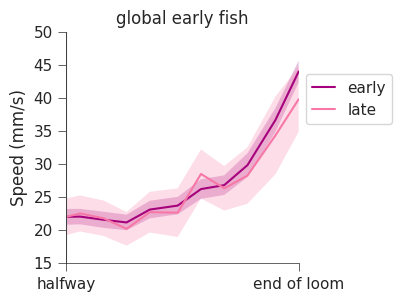

,early_fish_1,early_fish_2,early_fish_3,early_fish_4,early_fish_5,early_fish_6,early_fish_7,early_fish_8,early_fish_9,early_fish_10,...,late_fish_26,late_fish_27,late_fish_28,late_fish_29,late_fish_30,late_fish_31,late_fish_32,late_fish_33,late_fish_34,late_fish_35
0,6.172371,15.153770,29.928928,13.540386,12.196275,6.796851,46.720806,35.551912,33.710369,29.028675,...,33.531515,12.416284,22.727809,36.650336,18.694550,32.090027,11.323296,3.037678,26.346132,48.648155
1,8.931636,13.752976,15.776255,43.322295,8.789452,23.155350,38.558594,8.447298,10.257836,32.536199,...,38.899171,18.100339,12.620866,23.851747,16.170458,15.807695,8.811468,3.037678,23.241360,49.555650
2,36.016667,24.911508,8.585680,15.701502,27.151039,15.018963,46.197923,28.270537,11.265308,61.185145,...,39.474049,8.934540,12.468987,13.118331,6.220592,10.571706,6.526238,3.037678,28.844311,36.417565
3,37.549689,12.345205,5.451504,45.584277,30.574677,29.939729,27.428549,54.593268,16.432829,20.215420,...,30.173275,10.605776,4.894846,35.689484,14.327787,28.662077,4.921469,3.037678,8.661136,24.753850
4,22.442973,35.556201,6.469256,42.497820,12.703115,25.436765,49.906824,14.373510,8.489832,30.728817,...,26.501356,5.971101,4.506601,24.300462,17.849271,21.091516,10.002307,3.037678,9.281841,16.496234
5,16.172247,32.811804,6.914757,38.915763,33.782417,45.676816,12.566233,17.091009,27.128277,36.748491,...,40.417957,13.083867,3.806855,17.020384,7.611552,13.895420,10.412033,3.037678,6.672587,34.382292
6,17.491586,15.649055,14.319411,64.193221,16.517479,34.098742,70.908934,21.315136,18.920697,13.466355,...,37.911476,58.760823,3.608096,31.477222,6.229566,8.323442,5.943740,3.037678,31.893517,94.307569
7,20.621850,9.021817,7.674714,36.697972,23.338268,6.912386,25.122063,22.994644,10.851203,14.414793,...,26.694613,34.740212,3.302211,19.461422,20.390124,30.542073,3.355451,3.037678,25.410102,37.689710
8,10.596303,9.671799,9.180994,46.386715,18.517670,12.018424,24.013292,5.440093,9.504711,34.812470,...,36.973798,55.587739,2.585635,30.737376,22.278898,21.723446,2.187329,3.037678,14.163246,55.043100
9,9.792112,7.780776,20.865474,45.043617,32.637668,37.906959,24.162957,5.003352,3.971618,32.599487,...,60.850254,42.964061,2.349360,37.020618,8.022159,34.755967,3.052170,3.150192,11.600806,48.851013


In [ ]:
subpanel = '2h'
hex_colorz = ['#a6017c', '#f778a6'];
categories = ['early','late']

# make time_sec relative to tap for plotting
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# masks
early_fish = (ind_fish_df['ind_status'] == 'early')*(ind_fish_df['group_status'] == 'early')
late_fish = (ind_fish_df['ind_status'] == 'early')*(ind_fish_df['group_status'] == 'late')

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

# plot
plt.figure(figsize=[3, 3])
plt.plot(rel_sec, np.nanmean(early_speeds,axis=0),color=hex_colorz[0],label='early')
plt.fill_between(rel_sec,np.nanmean(early_speeds,axis=0)-stats.sem(early_speeds,axis=0),\
                 np.nanmean(early_speeds,axis=0)+stats.sem(early_speeds,axis=0),color=hex_colorz[0],alpha=0.25,lw=0)
plt.plot(rel_sec, np.nanmean(late_speeds,axis=0),color=hex_colorz[1],label='late')
plt.fill_between(rel_sec,np.nanmean(late_speeds,axis=0)-stats.sem(late_speeds,axis=0),\
                 np.nanmean(late_speeds,axis=0)+stats.sem(late_speeds,axis=0),color=hex_colorz[1],alpha=0.25,lw=0)
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5)
plt.axvline(0.5,color='gray'); plt.ylim(15,50); plt.xlim(0.5,1)
plt.xticks([0.5,1],['halfway','end of loom'])
plt.ylabel('Speed (mm/s)')
sns.despine(); plt.title(f'global early fish')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, s in enumerate(early_speeds): series_dict[f'early_fish_{i+1}'] = pd.Series(s)
for i, s in enumerate(late_speeds): series_dict[f'late_fish_{i+1}'] = pd.Series(s)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## 2i - stats of 2h

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2i


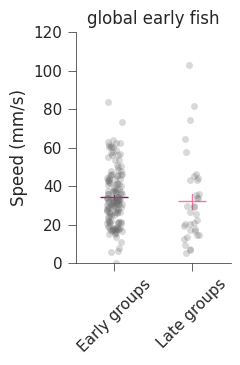

,early_fish_in_early_group,early_fish_in_late_group
0,31.447789,35.506342
1,31.238827,20.281055
2,18.485549,33.712828
3,58.626940,12.438630
4,37.352548,45.317862
...,...,...
148,43.346916,NaN
149,33.297634,NaN
150,36.190439,NaN
151,18.589660,NaN


Ns, means, and  sems for data:
early: (N=153) 34.289, 1.177
late: (N=35) 32.142, 3.773

Normality test (Shapiro-Wilk):
Group Early groups: W = 0.976, p = 0.009
Group Late groups: W = 0.877, p = 0.001
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 3165.000, p = 9.3560694078e-02


In [ ]:
subpanel = '2i'
categories = ['early','late']; hex_colorz = ['#a6017c', '#f778a6'];

# masks
early_fish = (ind_fish_df['ind_status'] == 'early')*(ind_fish_df['group_status'] == 'early')
late_fish = (ind_fish_df['ind_status'] == 'early')*(ind_fish_df['group_status'] == 'late')

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

# get speed in the last 20% time
early_sp = np.nanmean(early_speeds[:,-int(bin_num*0.2):],axis=1)
late_sp = np.nanmean(late_speeds[:,-int(bin_num*0.21):],axis=1)

group_values = {'Early groups': early_sp, 'Late groups': late_sp}

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='dimgray',alpha=0.25)
sns.pointplot(data=group_values,palette=hex_colorz,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Speed (mm/s)'); plt.xticks(rotation=45); plt.ylim(0,120)
sns.despine(); plt.title(f'global early fish')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
series_dict['early_fish_in_early_group'] = pd.Series(early_sp)
series_dict['early_fish_in_late_group'] = pd.Series(late_sp)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# stats
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{categories[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

## 2j - late fish speed time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2j


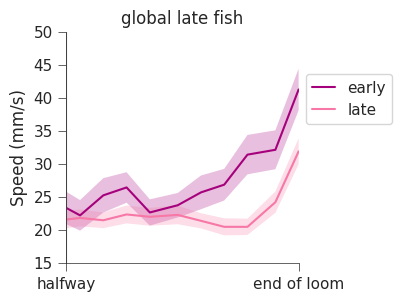

,early_fish_1,early_fish_2,early_fish_3,early_fish_4,early_fish_5,early_fish_6,early_fish_7,early_fish_8,early_fish_9,early_fish_10,...,late_fish_130,late_fish_131,late_fish_132,late_fish_133,late_fish_134,late_fish_135,late_fish_136,late_fish_137,late_fish_138,late_fish_139
0,4.901986,44.906560,12.430904,7.526154,18.620943,11.809946,18.764294,28.858400,26.157742,23.200679,...,22.549656,36.032971,38.942049,0.455508,35.172102,48.238637,5.676338,6.463285,27.812515,34.233569
1,3.023778,29.088242,39.105253,13.493133,12.854713,7.990601,10.255403,18.528611,25.986021,45.869835,...,12.493499,16.310887,20.657617,0.455508,27.016786,51.203131,6.936055,11.941108,16.649681,66.602200
2,4.086065,70.194628,16.033574,8.105274,15.360466,12.134103,33.102774,11.170712,13.683657,26.927034,...,9.918688,11.001981,12.103831,0.455508,27.966520,28.092209,3.816739,8.654318,25.312902,67.169297
3,18.916736,70.194628,19.965846,8.267910,10.049982,9.728345,48.520008,35.065083,16.592709,49.605606,...,43.282399,14.179618,9.779147,0.455508,14.940573,18.593349,3.913586,14.510289,13.807090,48.260839
4,13.232421,61.966753,44.653146,5.084687,14.280977,7.286235,27.817094,25.792061,14.638873,41.471345,...,28.343787,32.859829,16.617928,0.455508,22.658669,28.730705,5.505464,5.483048,24.494934,9.691123
5,27.232452,58.200417,28.943724,6.816980,29.927867,17.553712,32.064194,33.182322,5.335441,32.593859,...,18.884687,11.592149,31.998282,0.455508,21.267455,46.771954,5.306067,3.166543,15.393464,43.295490
6,16.621266,49.742631,16.872957,10.591668,18.277037,21.233285,30.169125,39.782397,3.695725,47.551959,...,20.545219,20.780803,15.261927,0.455508,11.480035,27.006487,2.432001,2.855107,9.549128,15.277963
7,9.401813,28.605437,39.461219,16.296037,23.983069,12.806520,36.562029,19.376417,15.374990,24.211494,...,41.447487,16.620688,12.027893,0.455508,8.345045,23.071245,3.364878,2.918526,19.597274,21.802321
8,27.017604,32.208247,23.861240,11.751198,18.152432,15.798588,13.546550,9.596742,5.209370,62.562877,...,32.128274,24.635778,8.771305,0.455508,10.799060,36.266944,4.704770,9.879754,10.158837,27.125541
9,12.958922,24.764425,6.160189,11.355571,12.514041,7.719260,37.777967,33.096493,14.247829,56.855987,...,67.104602,9.577637,17.256272,0.455508,23.301447,18.832976,3.863687,5.042595,38.827740,19.329338


In [ ]:
subpanel = '2j'
hex_colorz = ['#a6017c', '#f778a6'];
categories = ['early','late']

# make time_sec relative to tap for plotting
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# masks
early_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'early')
late_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'late')

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

# plot
plt.figure(figsize=[3, 3])
plt.plot(rel_sec, np.nanmean(early_speeds,axis=0),color=hex_colorz[0],label='early')
plt.fill_between(rel_sec,np.nanmean(early_speeds,axis=0)-stats.sem(early_speeds,axis=0),\
                 np.nanmean(early_speeds,axis=0)+stats.sem(early_speeds,axis=0),color=hex_colorz[0],alpha=0.25,lw=0)
plt.plot(rel_sec, np.nanmean(late_speeds,axis=0),color=hex_colorz[1],label='late')
plt.fill_between(rel_sec,np.nanmean(late_speeds,axis=0)-stats.sem(late_speeds,axis=0),\
                 np.nanmean(late_speeds,axis=0)+stats.sem(late_speeds,axis=0),color=hex_colorz[1],alpha=0.25,lw=0)
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5)
plt.axvline(0.5,color='gray'); plt.ylim(15,50); plt.xlim(0.5,1)
plt.xticks([0.5,1],['halfway','end of loom'])
plt.ylabel('Speed (mm/s)')
sns.despine(); plt.title(f'global late fish');
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, s in enumerate(early_speeds): series_dict[f'early_fish_{i+1}'] = pd.Series(s)
for i, s in enumerate(late_speeds): series_dict[f'late_fish_{i+1}'] = pd.Series(s)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## 2k - stats of 2j

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2k


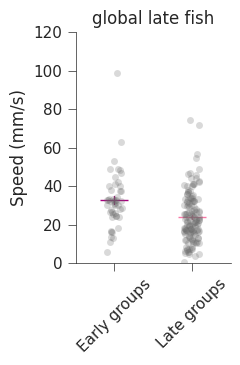

,early_fish_in_early_group,early_fish_in_late_group
0,18.322018,11.885363
1,34.315474,17.181067
2,16.594119,4.761862
3,16.169036,6.299609
4,28.945630,37.495029
...,...,...
134,NaN,71.981375
135,NaN,19.859463
136,NaN,7.195622
137,NaN,42.777666


Ns, means, and  sems for data:
early: (N=49) 32.903, 2.133
late: (N=139) 24.241, 1.103

Normality test (Shapiro-Wilk):
Group Early groups: W = 0.869, p = 0.000
Group Late groups: W = 0.949, p = 0.000
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 4699.000, p = 7.8879648226e-05


In [ ]:
subpanel = '2k'
categories = ['early','late']; hex_colorz = ['#a6017c', '#f778a6'];

# masks
early_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'early')
late_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'late')

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

# get speed in the last 20% time
early_sp = np.nanmean(early_speeds[:,-int(bin_num*0.2):],axis=1)
late_sp = np.nanmean(late_speeds[:,-int(bin_num*0.21):],axis=1)

group_values = {'Early groups': early_sp, 'Late groups': late_sp}

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='dimgray',alpha=0.25)
sns.pointplot(data=group_values,palette=hex_colorz,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Speed (mm/s)'); plt.xticks(rotation=45); plt.ylim(0,120)
sns.despine(); plt.title(f'global late fish')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
series_dict['early_fish_in_early_group'] = pd.Series(early_sp)
series_dict['early_fish_in_late_group'] = pd.Series(late_sp)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# stats
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{categories[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

## 2l - not informed fish speed time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2l


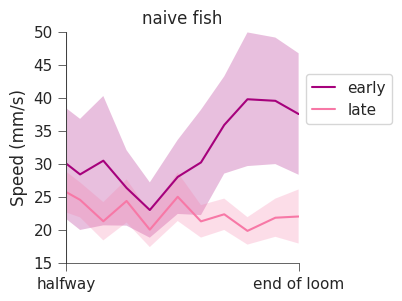

,early_fish_1,early_fish_2,early_fish_3,early_fish_4,early_fish_5,early_fish_6,early_fish_7,early_fish_8,early_fish_9,early_fish_10,...,late_fish_24,late_fish_25,late_fish_26,late_fish_27,late_fish_28,late_fish_29,late_fish_30,late_fish_31,late_fish_32,late_fish_33
0,44.906560,11.354460,7.910896,29.842733,16.766469,14.906500,15.735048,34.680223,14.826148,19.247604,...,23.916728,12.758547,5.658250,7.327893,3.429074,20.637125,11.877918,51.155262,0.455508,35.172102
1,29.088242,18.146278,28.254971,35.491595,46.815368,13.710379,29.165536,21.106076,9.639306,21.793020,...,6.470228,13.063262,3.769260,91.498891,2.401190,16.574739,14.828368,21.859688,0.455508,27.016786
2,70.194628,19.353801,20.752059,28.078052,20.528997,12.122767,41.901813,27.149596,11.509348,78.568402,...,7.542399,16.920566,4.193370,54.680307,6.933395,11.203598,9.702292,22.467542,0.455508,27.966520
3,70.194628,24.675844,9.581873,25.060593,88.110179,16.234131,18.584679,59.000109,11.786520,29.034488,...,15.148364,15.626115,3.639268,32.023697,3.661885,8.031603,11.406338,22.467542,0.455508,14.940573
4,61.966753,31.912370,5.317205,15.312681,41.752715,8.104118,26.710171,68.585099,8.416500,18.533007,...,17.253372,20.367546,4.219102,60.076296,3.027768,25.626632,12.016110,22.467542,0.455508,22.658669
5,58.200417,31.354721,5.545605,14.517797,34.258988,17.980547,27.195491,56.997352,13.303444,19.193044,...,16.634342,29.376336,4.242876,42.477648,4.607447,19.604758,7.043384,22.467542,0.455508,21.267455
6,49.742631,11.602680,33.038121,37.883945,67.531605,9.386074,14.368743,51.648302,6.509768,30.717479,...,9.486302,29.321332,4.147829,45.635287,8.398377,19.275752,5.801340,22.467542,0.455508,11.480035
7,28.605437,8.296670,15.905445,15.886296,65.585840,17.382674,34.443083,41.870692,10.167715,91.334375,...,19.254958,14.567437,3.960429,63.912007,5.523004,8.386100,5.242052,22.467542,0.455508,8.345045
8,32.208247,19.940970,7.941779,11.432611,25.895120,21.938134,25.954230,25.507545,11.060503,96.199744,...,8.798497,10.515101,4.765807,44.876309,4.575326,8.971201,10.193737,22.563266,0.455508,10.799060
9,24.764425,18.746365,25.160803,7.668977,60.385018,26.579556,21.478943,33.346396,5.297788,93.483596,...,17.420303,17.202330,5.348502,38.258361,7.121502,60.726678,9.624956,43.402377,0.455508,23.301447


In [ ]:
subpanel = '2l'
hex_colorz = ['#a6017c', '#f778a6'];
categories = ['early','late']

# make time_sec relative to tap for plotting
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# masks
early_fish = (np.isnan(ind_fish_df['ind_time']))*(ind_fish_df['group_status'] == 'early')
late_fish = (np.isnan(ind_fish_df['ind_time']))*(ind_fish_df['group_status'] == 'late')

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

# plot
plt.figure(figsize=[3, 3])
plt.plot(rel_sec, np.nanmean(early_speeds,axis=0),color=hex_colorz[0],label='early')
plt.fill_between(rel_sec,np.nanmean(early_speeds,axis=0)-stats.sem(early_speeds,axis=0),\
                 np.nanmean(early_speeds,axis=0)+stats.sem(early_speeds,axis=0),color=hex_colorz[0],alpha=0.25,lw=0)
plt.plot(rel_sec, np.nanmean(late_speeds,axis=0),color=hex_colorz[1],label='late')
plt.fill_between(rel_sec,np.nanmean(late_speeds,axis=0)-stats.sem(late_speeds,axis=0),\
                 np.nanmean(late_speeds,axis=0)+stats.sem(late_speeds,axis=0),color=hex_colorz[1],alpha=0.25,lw=0)
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5)
plt.axvline(0.5,color='gray'); plt.ylim(15,50); plt.xlim(0.5,1)
plt.xticks([0.5,1],['halfway','end of loom'])
plt.ylabel('Speed (mm/s)')
sns.despine(); plt.title(f'naive fish')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, s in enumerate(early_speeds): series_dict[f'early_fish_{i+1}'] = pd.Series(s)
for i, s in enumerate(late_speeds): series_dict[f'late_fish_{i+1}'] = pd.Series(s)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## 2m - stats of 2l

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2m


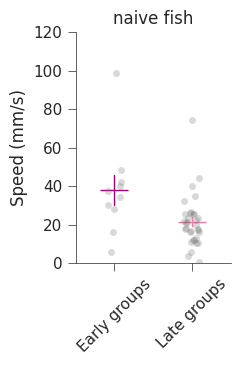

,early_fish_in_early_group,early_fish_in_late_group
0,34.315474,11.885363
1,37.755718,10.759737
2,28.079597,16.138790
3,16.351290,10.462470
4,42.189639,13.210475
5,48.269322,23.390868
6,98.904875,11.001995
7,40.210437,16.781086
8,5.623498,26.290447
9,30.173653,25.388749


Ns, means, and  sems for data:
early: (N=10) 38.187, 7.837
late: (N=33) 21.509, 2.340

Normality test (Shapiro-Wilk):
Group Early groups: W = 0.847, p = 0.053
Group Late groups: W = 0.848, p = 0.000
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 255.000, p = 1.0083749416e-02


In [ ]:
subpanel = '2m'
categories = ['early','late']; hex_colorz = ['#a6017c', '#f778a6'];

# masks
early_fish = (np.isnan(ind_fish_df['ind_time']))*(ind_fish_df['group_status'] == 'early')
late_fish = (np.isnan(ind_fish_df['ind_time']))*(ind_fish_df['group_status'] == 'late')

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

# get speed in the last 20% time
early_sp = np.nanmean(early_speeds[:,-int(bin_num*0.2):],axis=1)
late_sp = np.nanmean(late_speeds[:,-int(bin_num*0.21):],axis=1)

group_values = {'Early groups': early_sp, 'Late groups': late_sp}

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='dimgray',alpha=0.25)
sns.pointplot(data=group_values,palette=hex_colorz,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Speed (mm/s)'); plt.xticks(rotation=45); plt.ylim(0,120)
sns.despine(); plt.title(f'naive fish')
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
series_dict['early_fish_in_early_group'] = pd.Series(early_sp)
series_dict['early_fish_in_late_group'] = pd.Series(late_sp)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# stats
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{categories[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

## 2n - speed time series by number of early neighbor

In [ ]:
early_fish_counts = []; early_fish_pcts = []; group_speed_before_loom = []
for gp in np.unique(ind_fish_df['group_id']):
  early_fish_count = np.sum((ind_fish_df['group_id']==gp)*(ind_fish_df['ind_status']=='early'))
  gs = ind_fish_df['group_size'][ind_fish_df['group_id']==gp]

  # need to exclude all early fish groups
  if early_fish_count==gs[0]: continue

  early_fish_counts.append(early_fish_count)
  early_fish_pct = early_fish_count/gs[0]
  early_fish_pcts.append(early_fish_pct)
  # take only the late informed fish
  filter = (ind_fish_df['group_id']==gp)*(ind_fish_df['ind_status']=='late')
  speeds = ind_fish_df['speed_before_loom'][filter]
  group_speed_before_loom.append(np.nanmean(speeds,axis=0))

early_fish_counts = np.array(early_fish_counts); early_fish_pcts = np.array(early_fish_pcts)
group_speed_before_loom = np.array(group_speed_before_loom)
# print(len(np.unique(ind_fish_df['group_id'])), len(early_fish_counts), len(early_fish_pcts), len(group_speed_before_loom))

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2n


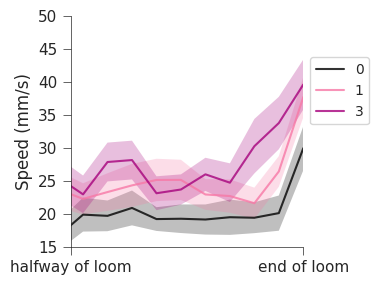

none N=13
0-1 N=17
3+ N=19


,none_early_neighbor_0,none_early_neighbor_1,none_early_neighbor_2,none_early_neighbor_3,none_early_neighbor_4,none_early_neighbor_5,none_early_neighbor_6,none_early_neighbor_7,none_early_neighbor_8,none_early_neighbor_9,...,3+_early_neighbor_9,3+_early_neighbor_10,3+_early_neighbor_11,3+_early_neighbor_12,3+_early_neighbor_13,3+_early_neighbor_14,3+_early_neighbor_15,3+_early_neighbor_16,3+_early_neighbor_17,3+_early_neighbor_18
0,10.152247,24.077391,9.479395,16.008852,16.575798,21.618949,18.081488,39.676814,25.109325,13.965615,...,20.028034,16.805184,26.300451,7.091716,11.379275,23.397987,19.597036,41.756543,26.127304,26.761430
1,15.999083,18.103797,9.529476,9.312818,16.513633,29.226100,16.052777,29.922799,25.828965,17.076681,...,17.841812,17.089171,41.890426,36.087890,20.583340,30.037435,11.211810,50.436395,19.819807,25.109376
2,17.651887,18.103675,17.645847,6.644368,15.578640,19.214599,20.359713,35.084522,24.334578,13.310828,...,27.808997,31.575478,45.246713,21.512191,12.825305,32.716893,13.603183,45.293972,31.343410,16.160747
3,15.332880,14.945803,27.354388,14.289731,21.958014,18.802420,23.560262,26.681523,15.868037,13.278570,...,23.637195,31.913141,44.628886,23.948135,15.514488,23.182934,11.004032,29.672429,23.057930,13.725240
4,11.124176,16.737457,20.983815,11.776531,21.556692,16.000915,26.882391,34.713007,16.533915,11.873807,...,28.824630,13.149002,30.978825,16.413259,17.252385,21.449087,19.637581,21.579887,16.109656,24.398149
5,15.948709,18.889456,20.021168,8.383118,17.391434,20.521847,21.247747,29.521499,14.721776,9.149714,...,22.629120,17.382029,31.709793,37.707841,12.692798,22.411664,14.083286,32.446799,23.381667,26.947393
6,13.905986,38.054777,26.443543,9.875404,13.171584,12.980935,23.335547,23.225426,17.565565,5.864353,...,22.511899,14.710991,39.555093,22.300678,9.109086,19.212387,16.701092,23.919313,18.969390,23.600475
7,9.788150,13.255626,21.942220,5.981188,12.908140,27.514028,23.685600,23.291603,29.077357,18.955403,...,35.484867,12.103404,28.966917,14.352370,13.525211,20.756623,16.294492,35.212825,65.744187,23.907169
8,6.677287,8.329368,11.402211,10.646399,20.685025,26.582293,19.048602,32.885156,17.908891,20.510227,...,23.564707,22.174354,39.289517,13.294935,12.626241,12.506484,23.837525,33.023250,39.761458,38.315433
9,9.756478,16.270218,25.254961,18.743802,42.124421,28.759782,42.203946,26.764007,40.806839,32.498179,...,37.532589,47.513319,51.536572,46.069754,63.118345,21.330100,35.249501,26.827099,25.098826,28.782323


In [ ]:
# run 2x first
subpanel = '2n'

# compare 0, 1-2, and 3+ early fish groups
hex_colors = ['#000000', '#f778a6', '#a6017c']

# make time in trial fraction
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# average
plt.figure(figsize=[3,3])

tmp = {n:[] for n in [0,1,3]}
for i, gp in enumerate([0,1,3]):
  if gp==0:
    filter = (early_fish_counts==gp)
    speeds = group_speed_before_loom[filter]; tmp[gp] = speeds
  if gp==1: # for 1-2 group
    filter = (early_fish_counts>0)*(early_fish_counts<3)
    speeds = group_speed_before_loom[filter]; tmp[gp] = speeds
  if gp==3: # for 3+ group
    filter = (early_fish_counts>2)
    speeds = group_speed_before_loom[filter]; tmp[gp] = speeds
  plt.plot(rel_time,np.nanmean(speeds,axis=0),color=hex_colors[i],alpha=0.8,label=f'{gp}')
  plt.fill_between(rel_time, np.nanmean(speeds,axis=0)-stats.sem(speeds,axis=0),\
                   np.nanmean(speeds,axis=0)+stats.sem(speeds,axis=0),color=hex_colors[i],alpha=0.25,lw=0)

plt.legend(bbox_to_anchor=(1,0.85),fontsize=10)
sns.despine(); plt.ylabel('Speed (mm/s)')
plt.ylim(15,50); plt.xlim(0.5,1); plt.xticks([0.5,1],['halfway of loom','end of loom'])
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()


# save source data into csv
series_dict = {}
for count, gp in zip(['none','0-1','3+'],[0,1,3]):
  col_name = f'early_fish_count_{count}'
  print(count, f'N={len(tmp[gp])}')
  for i, sp in enumerate(tmp[gp]):
    series_dict[f'{count}_early_neighbor_{i}'] = pd.Series(sp[10:])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## 2o - stats of 2n

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/2o


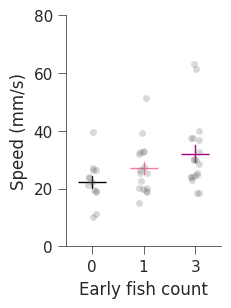

Ns, means, and  sems for data:
0: (N=13) 22.232, 2.070
1: (N=17) 27.099, 2.199
2: (N=19) 32.075, 2.835

Normality test (Shapiro-Wilk):
Group 0: W = 0.928, p = 0.321
Group 1: W = 0.905, p = 0.083
Group 3: W = 0.819, p = 0.002
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 6.505, p = 3.8675078927e-02

Dunn's post hoc test with bonferroni correction:  [0, 1, 3]
          1         2         3
1  1.000000  0.460182  0.032341
2  0.460182  1.000000  0.721882
3  0.032341  0.721882  1.000000


,none_early_neighbor,0-1_early_neighbor,3+_early_neighbor
0,10.031975,20.313572,18.322018
1,18.977497,32.730462,36.702350
2,21.260734,20.062609,37.541447
3,11.311698,25.454797,25.402193
4,22.222293,14.857313,24.193144
5,23.959259,18.794486,61.512306
6,27.068424,26.316912,63.214989
7,26.541548,32.538681,32.611240
8,26.339663,25.364647,30.335129
9,19.457040,22.557333,29.773516


In [ ]:
subpanel = '2o'

# get last 20% of speed
group_values = {n: [] for n in [0,1,3]}
for i, gp in enumerate([0,1,3]):
  if gp==0:
    filter = (early_fish_counts==gp)
    speeds = group_speed_before_loom[filter]
    sp = np.nanmean(speeds[:,-int(bin_num*0.2):],axis=1)
    group_values[gp] = sp
  if gp==1: # for 1-2 group
    filter = (early_fish_counts>0)*(early_fish_counts<3)
    speeds = group_speed_before_loom[filter]
    sp = np.nanmean(speeds[:,-int(bin_num*0.2):],axis=1)
    group_values[gp] = sp
  if gp==3: # for 3+ group
    filter = (early_fish_counts>2)
    speeds = group_speed_before_loom[filter]
    sp = np.nanmean(speeds[:,-int(bin_num*0.2):],axis=1)
    group_values[gp] = sp

plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='dimgray',alpha=0.25)
sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Speed (mm/s)'); plt.xlabel('Early fish count'); plt.ylim(0,80)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# stats
categories = [0,1,2]
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{categories[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

# save source data into csv
series_dict = {}
for count, gp in zip(['none','0-1','3+'],[0,1,3]):
  col_name = f'{count}_early_neighbor'
  series_dict[col_name] = pd.Series(group_values[gp])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)